# 2. Method 1: Spectrum Binning, Feature Hashing and OMS

## Goals:

In this notebook, we'll be exploring the following three core concepts:

1. [What Open Modification Search (OMS) is, and why it can be computationally expensive.](#21-open-modification-search-(OMS))

2. [How nearest neighbor algorithms work, and how they can be applied to OMS.](#22-clustering)

3. [Why raw mass spectra aren't compatible with clustering algorithms,](#why-vectorize-spectra) [and how Spectral Hashing enables spectra to be clustered.](#242-step-2-feature-hashing)

In [1]:
# @title Run this cell to import all necessary packages

#%pip install matplotlib

import spectrum_utils.plot as sup
from pyteomics import mzml
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from rapidhash import rapidhash
from IPython.display import display, Latex
from util import *

import importlib
import SpectrumWithTransformations as swt_module
import SpectrumWithTransformations
from spectrum_utils.proforma import Modification
from util import prove_similarity_preservation_plots_and_statistics

importlib.reload(swt_module)

<module 'SpectrumWithTransformations' from '/home/avni/source/repos/MS_spectra_encoding/SpectrumWithTransformations.py'>

## 2.1 Open Modification Search (OMS)

### 2.1.1 Spectral library search

For this tutorial, we'll be searching a data file where a single protein ([Carbonic Anhydrase](https://www.uniprot.org/uniprotkb/P00921/entry)) was digested with trypsin, then analyzed using LC-MS/MS. We start with a set of MS2 spectra, which we'll call *experimental spectra* (although they're also referred to as *query spectra*), and it's our job to try and identify these spectra by searching the data.

In order to identify peptides in the experimental data, we will compare the experimental spectra to *library spectra* in a spectral library. A spectral libary is a collection of spectra that are annotated with the peptides that gave rise to each spectrum. By comparing experimental spectra against library spectra, you can determine which peptides are present in your experimental data.  A full library search requires E*L comparisons, where E is the number experimental spectra and L is the number of library spectra. However, if both your spectral library and your experimental data are large, this can be a time consuming process!

In order to make the search less computationally expensive, we limit the comparisons. For each experimental MS2 spectrum, we know the mass of the peptide that was isolated and fragmented to generate the spectrum. For the library spectrum, we know the theoretical mass of the peptide that is associated with the spectrum. So, we can restric out spectrum-spectrum comparisons so that only library spectra where the peptide mass is close to the experimental spectrum's precursor mass are considered for comparison. This makes the search less computationally expensive, and therefore much faster!

We performed such a search. However, after it was done, we noticed that while we identified some of the spectra, corresponding to almost every peptide that can be produced by digesting Carbonic Anhydrase, a large portion of the spectra in our data go unmatched. What is happening here?

### 2.1.2 Post-translational modifications and open modification search

The answer is post-translational modifications, or PTMs\*. 

When we only looked for unmodified peptides, we had a relatively constrained set of theoretical spectra. However, once we start considering PTMs, our search space explodes. Any given PTM could appear on multiple residues. A peptide could even bear two or more PTMs. While PTMs are common, and biologically important, they make search considerably more difficult.

One way to account for PTMs is through **Open Modification Search (OMS).**

In OMS, every peptide in the database is considered as a potential match to every MS2 fragmentation spectrum. When a peptide-spectrum match is found, you can look for *mass shifts* to identify PTMs. All possible modifications are implicitly considered. You can imagine that this is very useful for discovering unexpected or novel modifications, but it comes at a cost - it is *very* computationally expensive because we can no longer reduce the number of spectrum-spectrum comparisons by filtering based on precursor mass.

We'll use **clustering** to cut down this search space in Section 2.2, grouping similar spectra so we only need to compare each experimental spectrum to a small representative subset of the library.

<details>
<summary><strong>Definition: Database Search and PTMs</strong> </summary>

---

#### Database Search

- *Database Search* is a way to check if a peptide from your sample already exists within a database.

  - That is, if you have a spectrum but don't know its identity, checking the relevant databases (eg. humans for human samples, e. coli for e. coli samples) allows you to use someone else's identification ("annotation", rather) of that spectrum.

    - This is done via a variety of algorithms (depends on the tool you're using) to determine how close of a match a spectrum is to the database's annotated spectrum.
    
    - Note that in traditional proteomics, we can safely consider only peptides from the database with the same mass as our fragmented spectra.

#### Post-Translational Modifications (PTMs)

- *Post Translational Modifications (PTMs)* are chemical "add-ons" to proteins after being synthesized. They allow a given protein to diversify and be useful far past the dictates of its transcription and synthesis, especially given that they are reversible. 

  - *PTMs* are also studied for their uses in cell signalling and dynamic regulation of protein function.
  
  - For a less abstract, numerical example of what PTMs are - an oxygen atom as a PTM on a peptide is called oxidation. Oxidation shifts the mass of the peptide by a certain $\text{m/z}$. So if a peak is at $\text{m/z} = 230$ with charge $z$, adding an oxygen atom (~16 Da) will shift it to approximately $230 + 16/z$.


---
</details>



## 2.2  Clustering Spectra

Instead of comparing every experimental spectrum to every possible library in our database, what if we only compared them to a subset of library spectra? If we could simplify our spectral library in such a way that we found a group of spectra that could be used to represent all other spectra in the library? Then, we only need to compare our experimental spectrum against this small subset of library spectra.

How would we go about this? The first step would be to find **clusters**, or groups of library spectra that are similar to one another. We can cluster all of our *library spectra* together based on their similarity, and then for each *experimental spectrum* we want to identify, we only need to compare it to one representative spectrum from each cluster (in practice, ANN-SoLo uses the centroid of each cluster rather than an actual spectrum, but the intuition is the same).

To reiterate - if we know the identity of one spectrum in a group ahead of time then we have a good idea of the identity of every spectrum in that cluster. This allows us to make just a single (or a few) comparisons per cluster instead of to every peptide in every cluster.

This approach is similar to the approach of [ANN-SoLo](https://pubs.acs.org/doi/full/10.1021/acs.jproteome.9b00291). This notebook will track closely with the methods used by ANN-SoLo, but the concept of clustering spectra is used much more broadly.

<center><img src="ANN-SoLo-Graphical-Abstract.jpeg" width="685" height="400"></center>

### 2.2.1 Clustering == Lego Sorting

To understand clustering better, imagine you're building a large Lego set with ~2,000 pieces.

*The naive approach:*
* Dump all pieces out at once
* For each instruction, search through the entire pile to find the piece you need

*The clustering approach:*
* Dump all pieces out at once
* First, sort pieces into piles by shape (2x4 studs, 1x2 studs, etc.)
* For each instruction, go directly to the relevant pile

If you grab any piece from a pile, it's representative of all pieces in that pile. This lets you quickly skip irrelevant piles. Now imagine 2,000,000 pieces! The efficiency gain becomes enormous.

> There's a balance between "too specific" (too many small piles) and "too generic" (piles with mixed pieces). The same applies to clustering spectra.

<center><img src="./lego-clusters.png" style="max-width:50vw;" alt="Lego Sorting"></center>


Note that not all pieces in a particular cluster are identical, but they're fairly close to one another! The same is true for spectra in a cluster - they may not be identical, but they're similar enough that we can make the same identification for all spectra in the cluster.

To reiterate:

| Lego | Spectra |
|:---:|:---:|
| Group similar pieces into piles | Group similar spectra into clusters |
| Identify one piece per pile | Identify one spectrum per cluster (using traditional search) |
| All pieces in pile share that identity | All spectra in cluster share that peptide identity |

### 2.2.2 Representing spectra in high-dimensional space and introducing similarity

The first step in building clusters is to determine which spectra are most similar to one another. In the case of mass spectra, it's not obvious how to do this! If a mass spectrum has a peak at 1000 m/z, and another spectrum has a peak at 1000.5 m/z, does this make them similar, or different? Should we focus more on the exact mass of the peaks, or the intensities?

We need some way of taking the complex data contained in a mass spectrum and reducing it down into a format that is easier to work with. Namely, lists of numbers, so that we can measure how similar any two spectra are.

We'll define the actual similarity metric (cosine similarity + nearest-neighbor search) shortly in Section 2.6; for now, the key idea is that clustering requires every spectrum to live in the same numeric space.

<details>
<summary><strong>Visual introduction to representing points in (high dimensional) space</strong> </summary>

We can use lists of numbers in python (and math more generally) to do this.

For example, a point X = 10 like so:

```python
X = 10
list = [X]
plot(list)
```

![1 dimension](X.png)


With Y:


```python
X = 10
Y = 20

list = [X, Y]
plot(list)
```

![2 dimensions](Y.png)

And so on and so forth to basically represent as many dimensions as we want. When we get into points in 4 dimensions and higher, we can't visualize them as easily like we do in 1d, 2d, and 3d, but we will primarily just represent them as lists of numbers (or vectors, as they're more commonly called).

---

</details>

For this example, we'll try and represent mass spectra by two numbers, aka dimensions. That will allow us to represent a spectrum as a point in two-dimensional space, and will enable us to build clusters. The graphic below shows what this might look like.

<table style="border: none; border-collapse: collapse;">
<tr style="border: none;">
<td style="border: none; text-align: center; vertical-align: top; padding: 10px;">
<img src="Clustering-1.jpeg" height="1000"><br>
<em>Here, we represent every spectrum in 2 dimensions. For dimension one, we sum up every peak below 500 m/z. For dimension 2, we sum up every peak above 500 m/z. This gives us a 2 dimensional representation of each spectrum. We'll start with two known library spectra that represent peptides A and B.</em>
</td>
<td style="border: none; text-align: center; vertical-align: top; padding: 10px;">
<img src="Clustering-2.jpeg" height="1000"><br>
<em>Here, we start adding more and more spectra. By transforming every new spectrum into the same two-dimensional space, it's easy to compare the incoming experimental spectra to the library spectra that represent A and B, and see which of the library spectra the experimental spectrum is more similar to.</em>
</td>
</tr>
</table>

## 2.3 Spectrum Binning

The clustering example above reveals an important requirement, that every spectrum must be represented as a list of the **same length**, where each position means the same thing across all spectra. Only then can we meaningfully compare them. This is given by the fact that we were plotting them Dim 1 and Dim 2, and every spectrum had a value for both of those dimensions. We cannot have some spectra with values for Dim 1 and Dim 2, and other spectra with values for Dim 3 and Dim 4. That would make it impossible to compare them.

Since each position has to mean the same thing across all spectra, a really intuitive way to do this is simply to have each position correspond to a 1 Th (a Thompson (Th) is just one m/z) bin.

We do this by dividing the m/z axis into fixed-width bins and recording each bin's intensity:

* Bin 99: m/z 99–100 → intensity 0
* Bin 100: m/z 100–101 → intensity 1200
* Bin 101: m/z 101–102 → intensity 500
* Bin 102: m/z 102–103 → intensity 0

This gives us a vector, or a list of numbers, like $[..., 0 , 1200, 500, 0, ...]$ where we've divided the m/z axis into bins of 1 Th width, and recorded the intensity in each bin. 

**The spectra that we're dealing with only go up to 2000 m/z, so we can represent every spectrum as a fixed vector of length 2000, where each position corresponds to a specific m/z bin, and 0 at a slot = no intensity at any m/z's that fall into that bin.**

**Why keep the zeros?** It might seem wasteful. Why not just list the intensities we actually observed? The problem: a bare list like $[1200, 500]$ loses all m/z information. We'd have no idea *which m/z* those intensities came from. The zeros are placeholders that tie each value to a specific m/z range. Also, since every spectrum is represented as a vector of the same length, we can meaningfully compare them, as we mentioned above.

Now, let's start looking at some real data. We'll begin by loading a mass spec data file. It is the one we described earlier, where a single protein was digested and analyzed via LC-MS/MS

In [ ]:
# @title The get_MS2_object function takes in a path and a scan number. This scan number tells it to retrieve the MS2 corresponding to the scan number from that mzML file.

full_calibrated_mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML' # Throughout our examples, we'll use this as our one sample mzml file. 

ms2_spectrum_5672 = get_MS2_object(mzml_path=full_calibrated_mzml_path, scan=5672)

plot_MS2(ms2_spectrum=ms2_spectrum_5672)

Within the spectrum, the peaks are stored as two separate arrays: an array of m/z values, and an array of intensity values. Each peak can be reconstructed by combining the m/z value and intensity value in their respective arrays.

In [ ]:
# grab the m/z values for each peak from the ms2 object
spectrum_mz = ms2_spectrum_5672.mz
# grab the intensity values for each peak from the ms2 object
spectrum_int = ms2_spectrum_5672.intensity
# Calculate the bin indices for each peak
BIN_WIDTH = 1
bin_indices = np.floor(spectrum_mz / BIN_WIDTH).astype(int)

# Display the peaks  as a table
df = pd.DataFrame({'m/z': spectrum_mz, 'Intensity': spectrum_int, 'Bin Index': bin_indices})
display(df.style.format({'m/z': '{:.2f}', 'Intensity': '{:.2f}', 'Bin Index': '{:.0f}'}))

,m/z,Intensity,Bin Index
0,129.10,2174.82,129
1,147.11,3145.84,147
2,185.16,9230.92,185
3,186.17,2883.78,186
4,213.16,4380.56,213
5,229.12,2282.99,229
6,260.20,3063.12,260
7,298.14,2072.46,298
8,300.16,3142.87,300
9,328.19,2672.69,328


#### Binning Strategies & Resolution

We've shown *why* we need to bin spectra, but we've haven't considered *how* we bin spectra. We simply defaulted to using 1 m/z bins. Let's now explore the implications of this choice, and what happens if we use different binning strategies.

Consider a toy spectrum with two peaks:

| Peak | m/z | Intensity |
| --- | ---: | ---: |
| A | 500.12 | 1200 |
| B | 500.62 | 900 |

With **1 m/z bins**, both peaks land in the same bin covering 500 to 501 m/z. That means they **collide** and get stored as a single value with total intensity 2100. We keep the total signal, but lose the fact that there were two separate peaks. It's obvious that if we use smaller bins, we'll have higher resolution and experience fewer collisions. 

However, we can't just make bins arbitrarily small; we must choose a size that is both fine enough to preserve information and realistic for mass spectrometer accuracy.

Mass spectrometers have physical limits on how precies they can be. While a spectrometer might output a value like $ m/z =  10.023130 $, it cannot actually distinguish measurements to that level of precision. In practice, the precision of an m/z value depends on the type of mass spectrometer that was used, with precision ranging from < 1 m/z to > 0.001 m/z!

We will choose 0.04 m/z bins, as this strikes a balance between preserving information and being realistic about the precision of mass spectrometers.

With **0.04 m/z bins**, those same peaks land in different bins:

- 500.12 goes into the bin from 500.12 to 500.16
- 500.62 goes into the bin from 500.60 to 500.64

Now the encoded spectrum preserves both peaks separately.

This is the main tradeoff in binning:

- **Larger bins** give shorter vectors, but cause more collisions and lose detail.
- **Smaller bins** preserve more structure, but create much larger vectors.

If we cover a 0 to 2000 m/z range, the vector length changes a lot:

- **1.00 m/z bins** -> about 2,000 buckets
- **0.04 m/z bins** -> about 50,000 buckets

<details><summary><strong>Read more about mass spectrometer "resolution"</strong></summary>

Thus far, we've used the term "resolution" and "accuracy" somewhat loosely and interchangeably, but resolution is a well defined idea.

The intuition is that after we get past a certain m/z value, the mass spectrometer has a harder time distinguishing between peaks that are close together.

1. In Orbitrap instruments, as ions rotate in the orbitrap, we grab m/z values based on a fourier transform (fancy words for approximating functions of waves) of the frequency of which ions oscillate from side to side.
2. The higher the mass of the ions, the more slowly they oscillate, and since ions are accelerated to the same kinetic energy, heavier ions end up moving more slowly:

$$\text{KE} = 1/2mv^2$$
 and therefore their electric-signals-as-waves will be harder to distinguish from one another because we have less cycles/data to approximate from.

This makes algebraic sense too. In fact, the resolution $R$ is defined as $$ R = \frac{m/z}{\Delta (m/z)} =  \frac{m}{\Delta m} $$


Binning (and collision) visualization:

<video controls>
  <source src="Binning.mp4" type="video/mp4">
</video>




Now, we can set our bin widths and bin our example spectra.

We've already chosen our bin width (0.04 Da). Now we'll define a function to convert m/z values to their binned index.

For example: 129.103 m/z → index 3227

In [37]:
BIN_WIDTH = 0.04
LENGTH = 50000.

print(f"We have to fit our m/zs into bins by rounding them to the nearest {BIN_WIDTH}")
print(f"The length of our array will be {LENGTH}")

def to_idx(mz):
    """
    Convert m/z value to a sparse vector index.
    """
    # concretely: 129.103 // 0.04 == 3227
    return int(mz // BIN_WIDTH) # rounds down to nearest 0.04.

We have to fit our m/zs into bins by rounding them to the nearest 0.04
The length of our array will be 50000.0


With 50,000 possible bins but only 24 peaks in this spectrum, most bins are empty. Storing ~50,000 zeros is wasteful right now as well, so instead we'll use a dictionary mapping `{mz_bin: intensity}`.


<details><summary><strong>Sparse Vectors</strong></summary>

This dictionary stores only the non-zero entries:

Instead of:
```python
[0, 0, 0, ..., 2174.818, 0, 0, ..., 3145.84, 0, 0, ..., 0]  # 50,000 entries
```

We store:
```
{12910: 2174.818, 14711: 3145.84, ...}  # Only the 24 entries that matter
```

In [38]:
# @title Create the sparse representation map from m/z indices to intensities, then visualize the results

mz_intensity_map = {}
# Populate the sparse vector with our spectrum data
for i, mz in enumerate(spectrum_mz):
    # Convert each m/z to its corresponding index
    mz_index = to_idx(mz)
    # Store the intensity
    mz_intensity_map[mz_index] = spectrum_int[i]

    from IPython.display import display
rows = []
for bin_idx, intensity in sorted(mz_intensity_map.items()):
    orig_mz = next((mz for mz in spectrum_mz if to_idx(mz) == bin_idx), None)
    rows.append({'m/z bin': bin_idx, 'Intensity': intensity, 'Original m/z': orig_mz})
df_mz = pd.DataFrame(rows)
display(df_mz.style.format({'Intensity': '{:.3f}', 'Original m/z': '{:.4f}'}))

print(f"Total entries: {len(mz_intensity_map)} (instead of ~50,000 zeros!)")

,m/z bin,Intensity,Original m/z
0,3227,2174.818,129.1023
1,3677,3145.840,147.1128
2,4629,9230.925,185.1649
3,4654,2883.776,186.1681
4,5328,4380.564,213.1598
5,5727,2282.987,229.1184
6,6504,3063.123,260.1971
7,7453,2072.459,298.1401
8,7503,3142.870,300.1557
9,8204,2672.693,328.1873


Total entries: 24 (instead of ~50,000 zeros!)


#### Step 1 Complete! 

 We have a sparse, binned, vector representation of our spectrum.

 ---
 

## 2.4 Feature Hashing and the Ann-SoLo Approach

Now that we have chosen 0.04 Da bins, we can represent that particular spectrum which we plotted and analyzed earlier as a list with length 50,000. We can also call these "dimensions," and note that we've put just one spectrum in a 50,000-dimensional vector. 

You might guess that this is a massive problem for clustering and computational efficiency, and is the main motivation behind the ANN-SoLo approach.

What if, instead of using 50,000 dimensions, we had a *magic function* that could compress our spectra into a lower-dimensional space while preserving their relative distances? 

This would make it so clusters of spectra that WOULD have clustered in this ultra-high-dimensional space, also cluster in the lower dimensional space. This is where *feature hashing* comes in. This would allow us to cluster spectra much more efficiently, especially given the fact that this is all in the context of *Open Modification Search*, so our search space is that much larger. We will see this in action later, but I wanted to motivate this idea first.


<figure style="text-align:center">
  <img src="https://pubs.acs.org/cms/10.1021/acs.jproteome.9b00291/asset/images/medium/pr9b00291_0001.gif" width="685" />
  <figcaption style="font-size:1.0em;">ANN-SoLo Plan.</figcaption>
</figure>

We'll be implementing the code for the two steps visualized above:

1. *Spectrum Binning*: Convert spectrum to sparse vector using fine m/z bins (we've already seen numerical examples of this!)

2. *Feature Hashing*: Compress sparse vector to much smaller, fixed-size vector

### 2.4.1 Step 2: Feature Hashing

Now for the second step of the pipeline:

**Goal:** Compress the sparse vector (with indices up to 50,000) into a fixed-size vector of 1,000 dimensions.

#### Why do we need this?

Our sparse vector representation is memory efficient, but we still have a problem. It only stores non-zero entries as a dictionary, but it's not actually a vector. 

Two spectra with peaks at different m/z bins will have different dictionary keys, and there's no defined way to compute a distance between two dictionaries with mismatched keys. Clustering algorithms can't operate on them directly.

Clustering algorithms need fixed-size vectors. You can't easily compute distances between dictionaries with different keys. The obvious fix, converting each dictionary back into a full-length vector, doesn't help either, because the potential dimensionality is still huge. Even with only 24 entries, those indices span 0-50,000 and will need to be translated back into vectors for clustering. We'd be right back to a 50,000-dimensional representation, slow to store and slow to cluster over.

What we actually need is a function that maps our 24 sparse entries which are sitting at arbitrary indices anywhere from 0 to 50,000 directly into a fixed-size vector of length 1,000, without having to materialize all 50,000 dimensions in between. And crucially, it must do this in a way that **preserves similarity**: spectra that share many peaks should produce similar 1,000-dimensional vectors.

Here, I will once again remind you of our *magic function* from earlier. [Click this to review that cell again](#24-ann-solo-approach)

#### Hash Function

We need a function that maps arbitrary large indices (anywhere from 0 to 50,000) to a small fixed range (0 to 999) — consistently, cheaply, and without grouping nearby indices together. That's a textbook description of a hash function.

A *hash function* has 3 main properties, each of which directly satisfies one of the requirements above.

1. Randomness/Uniformity: They do not produce outputs of "groups" based on the input.

    For us, this means nearby m/z bin indices (e.g., 12910 and 12911) are just as likely to land in completely different buckets as they are to land in the same one. This is important: if a hash function *did* group nearby indices together, we'd just be re-doing a coarser version of m/z binning. Uniformity ensures the 24 peaks spread across the full 1,000-bucket space rather than piling into a small region of it.

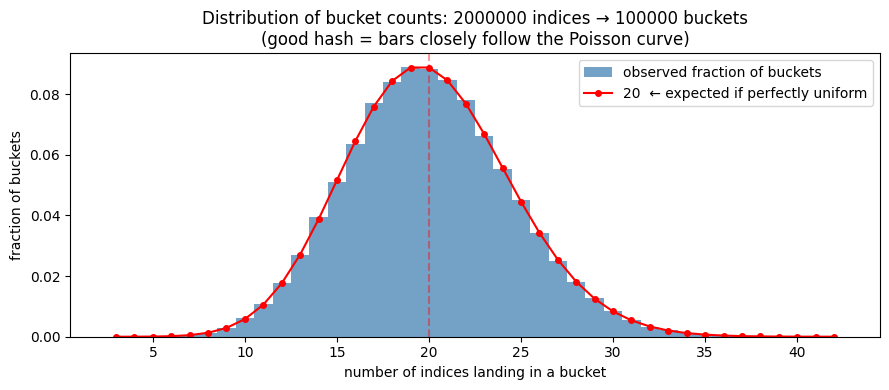

In [39]:
import mmh3
# Let's hash some values, and see how uniformly they distribute into buckets

DEMO_BUCKETS = 100000

def bucket_for_index(idx: int) -> int:
    return mmh3.hash(str(idx)) % DEMO_BUCKETS # encode ints => bytes for mmh3


N = 2000000
sample = np.random.choice(20000000, size=N, replace=False)
buckets_sample = [bucket_for_index(int(i)) for i in sample]
counts = np.bincount(buckets_sample, minlength=DEMO_BUCKETS)

expected_mean = N / DEMO_BUCKETS  # = 20 expected indices per bucket

from scipy.stats import poisson as _poisson

x = np.arange(counts.min(), counts.max() + 1)
bins = np.arange(counts.min() - 0.5, counts.max() + 1.5)

plt.figure(figsize=(9, 4))
plt.hist(counts, bins=bins, density=True, color="steelblue", alpha=0.75,
         label="observed fraction of buckets")
plt.plot(x, _poisson.pmf(x, expected_mean), "r-o", markersize=4, linewidth=1.5,
         label=f"{expected_mean:.0f}  ← expected if perfectly uniform")
plt.axvline(expected_mean, color="red", linestyle="--", alpha=0.4)
plt.xlabel("number of indices landing in a bucket")
plt.ylabel("fraction of buckets")
plt.title(f"Distribution of bucket counts: {N} indices → {DEMO_BUCKETS} buckets\n"
          f"(good hash = bars closely follow the Poisson curve)")
plt.legend()
plt.tight_layout()
plt.show()

2. Deterministic: Same input -> same output every time

    This is the property that makes similarity preservation possible. If spectrum A has a peak at bin 12910, and spectrum B also has a peak at bin 12910, both peaks will hash to the *exact same bucket* in both of their vectors. Shared m/z bins -> shared hash buckets -> similar hash vectors. Without this, two identical spectra could produce completely different hash vectors, and clustering would be meaningless.

In [40]:
hashed_string = mmh3.hash("this is the same string".encode())
same_hashed_string = mmh3.hash("this is the same string".encode())

print(hashed_string)
print(same_hashed_string)

assert(hashed_string == same_hashed_string)
print("Both hashes are identical")

-222214556
-222214556
Both hashes are identical


3. Incredibly Fast**: Efficiently computable

    We're hashing every peak in potentially millions of library spectra. A hash function runs in O(1) per element, fast enough that hashing adds negligible overhead compared to the search itself. This keeps the whole OMS preprocessing step tractable.

In [41]:
import timeit


def hash_varied_strings():
    for _ in range(100000):
        hash(f"this is string number {np.random.randint(0, 100000)}")


hash_time_varied = timeit.timeit(hash_varied_strings, number=1)


print(f"Time taken to hash 100,000 different strings: {hash_time_varied} seconds")

Time taken to hash 100,000 different strings: 0.37194770004134625 seconds


#### Our Magic Function == Hash Function

We wanted to map down from our sparse vector to a much lower dimensional one. Now we can see exactly why a hash function is that magic function — each of its three properties directly satisfies one of our requirements:

- **Fixed-size output** (from uniformity): `hash(index) % 1000` always returns a number in `[0, 999]`, giving every spectrum the same 1,000-dimensional vector regardless of which m/z bins had peaks.
- **Similarity preservation** (from determinism): Two spectra sharing a peak at bin 12910 will both map that peak to the same bucket. The more peaks two spectra share, the more their hash vectors overlap.
- **Tractable at scale** (from speed): Hashing an entire spectrum takes microseconds, keeping the OMS library preprocessing step fast even for large databases.

The takeaway from this is that we can reduce our computational burden with almost no downside (as we'll see in [Section 2.6](#26-verifying-that-hashing-preserves-similarity)) and thereby speed up traditionally very slow tasks like OMS considerably.

<details>
<summary><strong>[Optional] Why 1,000 buckets?</strong></summary>

We aim to balance two concerns:
- Large enough to minimize collisions (different peaks hashing to the same bucket)
- Small enough to be computationally efficient for clustering

1,000 is a reasonable middle ground for typical spectra.

---

</details>

Concretely, with 1,000 buckets, every sparse index from 0 to 49,999 maps to a bucket between 0 and 999:

$$\text{hash}(12910) \rightarrow 347 \quad \text{(bucket between 0 and 999)}$$

$$\text{hash}(14711) \rightarrow 102 \quad \text{(another bucket)}$$

Similar spectra (which we'd like to identify for clustering purposes) will have similar hash vectors because they share many of the same m/z bins, *which will hash to the same buckets* because of the deterministic nature of hash functions.

In [42]:
HASH_BUCKETS = 1000

#### The hash function

We'll use `mmh3`, a popular noncryptographic hash function, combined with the modulo operator to map any sparse index to a bucket in the range `[0, 999]`. Let's go back to the example spectrum we have been working with and have already binned.

In [45]:
def hasher(num: int) -> int:
    """
    Hash function that maps sparse indices to a fixed number of buckets.
    
    Input: Large sparse index (e.g., 12910)
    Output: Small bucket index (0 to 999)
    """
    # Convert integer to bytes for hashing (mmh3 expects byte input)
    byte_representation = str(num).encode()  # Convert number to string, then to bytes
    
    # Hash and mod to get bucket index in range [0, hash_buckets-1]
    return mmh3.hash(byte_representation) % HASH_BUCKETS

In [46]:
# @title Example: see how large indices get mapped to small buckets
print(f"Sparse index 12910 → bucket {hasher(12910)}")
print(f"Sparse index 14711 → bucket {hasher(14711)}")
print(f"Sparse index 87550 → bucket {hasher(87550)}")

Sparse index 12910 → bucket 822
Sparse index 14711 → bucket 493
Sparse index 87550 → bucket 456


#### Handling collisions

What happens when two different m/z bins hash to the same bucket? This is called a **collision**. 

We handle collisions by **adding the intensities together**. As we will see in a minute, this is acceptable because it, on average, happens rarely enough that it preserves similarity between vectors, which is the key idea behind combining clustering and hashing.

In [ ]:
# @title Populate our final hash vector with intensities, handling collisions by summation

# Initialize our final hash vector with all zeros
hash_vector = [0] * HASH_BUCKETS 

# Populate the hash buckets with intensities from our sparse map
for sparse_idx, intensity in mz_intensity_map.items():
    # Map the sparse index to a bucket
    bucket_idx = hasher(sparse_idx)
    
    # Add intensity to that bucket (handles collisions by summation)
    hash_vector[bucket_idx] += intensity

In [ ]:
# @title Display the hash vector

non_zero_buckets = [(i, val) for i, val in enumerate(hash_vector) if val > 0]

print(f"Hash vector has {len(non_zero_buckets)} non-zero buckets out of {HASH_BUCKETS} total\n")

nonzero_hash_df = pd.DataFrame(non_zero_buckets, columns=['Bucket', 'Intensity'])
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
display(nonzero_hash_df)

#### Step 2 complete!

We now have a fixed-size 1,000-dimensional hash vector, the exact format that clustering algorithms require.

Recall the original goal: speed up OMS by clustering similar spectra so we only compare each query to a small representative subset of the library. Now that every spectrum lives in the same fixed-size vector space, clustering is possible. But there's one thing left to verify: does compressing from 50,000 -> 1,000 dimensions actually preserve which spectra are similar to which? Section 2.6 answers that empirically.

---

## 2.5 Summary of the Spectrum Binning + Feature Hashing Pipeline


| Step | Representation | Size |
|------|----------------|------|
| **Original** | (m/z, intensity) pairs | 24 peaks |
| **Step 1: Binning** | Sparse vector (used dictionary for optimization) | ~88,000 |
| **Step 2: Hashing** | Fixed-size vector | 1,000 dimensions |

The property we need is that spectra that are similar in the original 50,000-dimensional binned space should remain similar after hashing to 1,000 dimensions. If that holds, clustering on hash vectors will correctly group similar spectra,  which is the core idea that makes this approach tractable for OMS.

## 2.6 Verifying that Hashing Preserves Similarity

We claimed that hashing "preserves similarity," that spectra which would cluster together in the original 50,000-dimensional binned space also cluster together in the compressed 1,000-dimensional space. This is the key claim that justifies using hashed vectors for OMS clustering, so let's verify it.

We'll do this in two parts: first define how we actually measure similarity between vectors, then run an empirical check on real spectra.

#### Measuring similarity with cosine similarity

The standard metric for comparing spectral vectors is *cosine similarity*.

It relies on the notion of a *dot product* to measure how similar two vectors are:

$$\vec{x} \cdot \vec{z} > \vec{x} \cdot \vec{y} \implies \vec{x} \text{ is more similar to } \vec{z} \text{ than to } \vec{y}$$

*Cosine similarity* is just a normalized dot product (scaled between 0 and 1).

<details>

<summary><strong>[Optional] Click to see the full cosine similarity formula and an example</strong> </summary>

$$\cos(\theta) = \frac{\vec{x} \cdot \vec{z}}{|\vec{x}| |\vec{z}|}$$

where $\theta$ is the angle between vectors. 

$\cos(\theta = 0) = 1$ => Identical direction

$\cos(\theta = 90) = 0$ => Perpendicular

$\cos(\theta = 180) = -1$ => Opposite direction


**Example:**

$\vec{x} = [0, 500, 0, 1200] \quad \text{(Spectrum A)}$

$\vec{z} = [0, 480, 0, 1190] \quad \text{(Spectrum B - similar)}$

$\vec{y} = [100, 30, 2000, 0] \quad \text{(Spectrum C - different)}$

**Dot products:**

$\vec{x} \cdot \vec{z} = (0)(0) + (500)(480) + (0)(0) + (1200)(1190) = 1,668,000$

$\vec{x} \cdot \vec{y} = (0)(100) + (500)(30) + (0)(2000) + (1200)(0) = 15,000$

Since $1,668,000 \gg 15,000$, spectra A and B would be clustered together, and spectrum C would be separate in this 4-dimensional space.



---
</details>


#### A Short Note on Clustering Algorithms

For demonstration, we can use any clustering algorithm. For this, we've chosen **k-means clustering**, which works as follows:

1. Initialize: Pick *k* random points as initial cluster centers
2. Assign: Assign each spectrum to the nearest center (by cosine similarity)
3. Update: Recompute each center as the mean of all assigned spectra
4. Repeat: Steps 2–3 until assignments stop changing

<br/>
<details><summary><strong>[Optional] Step-by-step k-means on an example (k=2)</strong></summary>

Imagine the pairwise cosine similarity matrix for 4 spectra:

|       | Spec0 | Spec1 | Spec2 | Spec3 |
|:-------:|:-----:|:-----:|:-----:|:-----:|
| Spec0 | 1.0   | 0.8   | 0.3   | 0.6   |
| Spec1 | 0.8   | 1.0   | 0.4   | 0.5   |
| Spec2 | 0.3   | 0.4   | 1.0   | 0.7   |
| Spec3 | 0.6   | 0.5   | 0.7   | 1.0   |

1. Initialize: pick Spec0 and Spec2 as initial centers.

1. Assign
- Spec0: similarity 1.0 to C1(Spec0) vs 0.3 to C2(Spec2) -> C1
- Spec1: similarity 0.8 to C1 vs 0.4 to C2 -> C1
- Spec2: similarity 0.3 to C1 vs 1.0 to C2 -> C2
- Spec3: similarity 0.6 to C1 vs 0.7 to C2 -> C2

Clusters: `C1 = {Spec0, Spec1}`, `C2 = {Spec2, Spec3}`

1. Update: recompute each center as the mean vector of its members.

2. Assign: re-check every spectrum against the updated centers. In this case no spectrum switches clusters -> converged.

Final result: `{Spec0, Spec1}` in one cluster, `{Spec2, Spec3}` in another.

---

</details>

Click play to go through a visual example (no sound), starting from the top.

<video controls>
  <source src="SimilarityPreservationComplete.mp4" type="video/mp4">
</video>


#### Empirical validation

The code below produces two outputs:

1. **Similarity scatter plot**: Each point is one pair of spectra. The x-axis is their cosine similarity in the original sparse-binned space; the y-axis is their cosine similarity in the hashed space. If hashing preserves similarity, all points should hug the diagonal.

2. **Cluster plots**: K-means is run on the shared t-SNE embedding of both representations. The resulting cluster labels are then shown for the unhashed view (left) and the hashed view (right) using the **same colors**. When the cluster shapes match across both panels, it means the same neighborhoods exist in both spaces: hashing has preserved the structure that clustering depends on.

The question we're asking is "if two binned spectra are very similar, are their hashed counterparts also very similar?"

And "if two binned spectra are dissimilar, do their hashed versions reflect that too?" This is the property that lets us trust clustering results on hashed vectors, and ultimately, the property that makes hashing useful for OMS.

> We are comparing binned spectra *to each other*, and hashed spectra *to each other*, not binned to hashed (which would be meaningless, since they have different lengths: ~50,000 vs. 1,000).

> **Note:** Some similarity loss is expected due to hash collisions, but this loss is typically small and acceptable for clustering purposes.

Computing pairwise similarities...



---
### SIMILARITY PRESERVATION METRICS
---
- **Pearson correlation**:  0.9836 (p-value: 0.00e+00)
- **Number of pairwise comparisons**: 44,850
- **Mean absolute error**: 0.0110
---


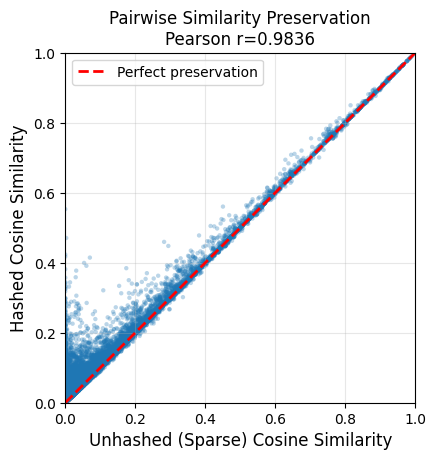

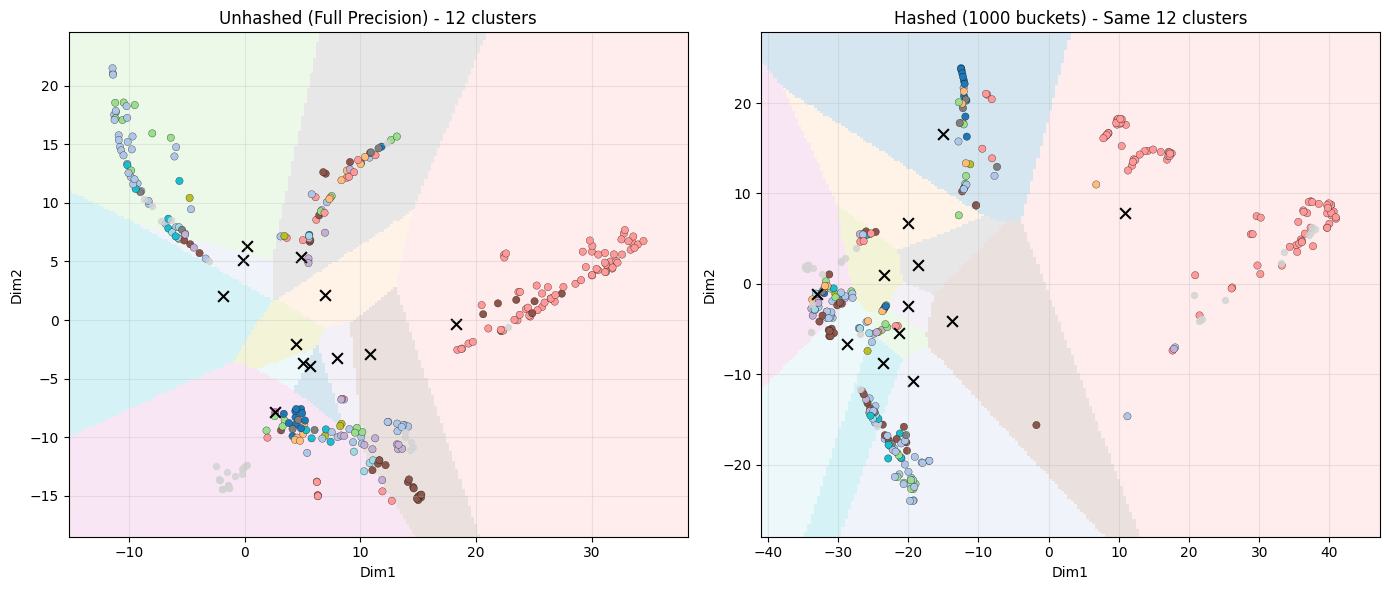

In [2]:
prove_similarity_preservation_plots_and_statistics("Biogen_ALS_Pilot_1A9_020120-calib-averaged.mzML", max_spectra=300) 

## 2.7 How does this speed up OMS?

We started this notebook with a problem: OMS is computationally expensive because every experimental spectrum must be compared against every library spectrum, with no precursor mass filter to narrow the search. We introduced clustering as the solution, and spent sections 2.3–2.6 building the machinery to make it work by binning, hashing, and verifying that the hashed representation preserves similarity.

Now let's put it all together and see how clustering on hashed vectors actually reduces the OMS search space.

In fact, let's imagine a fake embedding function:

```python
def embed_spectrum(mz_array: list[float], intensity_array: list[float]) -> list[float]:
    # Step 1: Bin → Step 2: Hash
    # ...
    return hash_vector  # length 1,000
```


**Phase 1: Build the Library (one-time preprocessing)**

1. For all spectra with **known identity** (from a spectral library), we call this function:

```python
hash_vector_library = embed_spectrum(library_spectrum.mz, library_spectrum.intensity)
```

2. Cluster all library hash vectors (we'll use cosine similarity).


> **Lego analogy:** Sort all your known Lego pieces into piles before you start building.

---

**Phase 2: Identify Unknown Spectra (query phase)**

3. For each unknown **query spectrum**:
```python
hash_vector_query = embed_spectrum(query_spectrum.mz, query_spectrum.intensity)
```

4. Find the nearest cluster representative using cosine similarity.

5. If similarity exceeds a threshold → assign the query the peptide identity of that cluster.

> **Lego analogy:** When you need a piece, check which pile it belongs to. All pieces in that pile share ~ the same identity.

---

**To Reiterate: Why does this work for modified peptides and OMS as a whole?**

A modified peptide shares MOST of its fragment ions with the unmodified version. The modification only shifts a subset of peaks. Because of this shared structure, the hash vectors remain similar enough that modified and unmodified versions cluster together - enabling identification regardless of PTMs.


---

## 2.8 Worked Example: Spectral Hashing End-to-End

Now let's see the complete pipeline on real data. We'll work with the peptide **AVVQDPALKPLALVYGEATSR**.

Below is its theoretical ion ladder:

In [ ]:
make_ion_ladder('AVVQDPALKPLALVYGEATSR')

Let's look at how this ion ladder can be plotted as a "spectrum." The purpose of this is to visualize the spread of m/z values. The intensity values here are meaningless.

In [ ]:
b_mz = [
    72.044114, 171.112528, 270.180942, 398.239520, 513.266463,
    610.319227, 681.356341, 794.440405, 922.535368, 1019.588132,
    1132.672196, 1203.709310, 1316.793374, 1415.861788, 1578.925108,
    1635.946572, 1764.989165, 1836.026279, 1937.073958, 2024.105986
]

y_mz = [
    2127.179698, 2028.111284, 1929.042870, 1800.984292, 1685.957349,
    1588.904585, 1517.867471, 1404.783407, 1276.688444, 1179.635680,
    1066.551616, 995.514502, 882.430438, 783.362024, 620.298704,
    563.277240, 434.234647, 363.197533, 262.149854, 175.117826
]

plot_theoretical_ions(b_mz, y_mz, 'AVVQDPALKPLALVYGEATSR')

Now let's plot a real spectrum and use the theoretical ions above to to annotate it. We'll start with scan 9970, the spectrum of the unmodified AVVQDPALKPLALVYGEATSR peptide.

In [ ]:
plot_MS2(get_MS2_object(full_calibrated_mzml_path, 9970, peptide = 'AVVQDPALKPLALVYGEATSR'))

Although there is inevitable noise that deviates from the theoretical ion ladder, this spectrum overall aligns really well with the ladder. In other words, **a significant proportion of this spectrum's total intensity is accounted for by the theoretical ion ladder.** Let's now look at a modified version of AVVQDPALKPLALVYGEATSR.

In [ ]:

seq = 'AVVQDPALKPLALVYGEATSR'
spec_left  = get_MS2_object(full_calibrated_mzml_path, 9970, peptide=seq) #AVVQDPALKPLALVYGEATSR
spec_right = get_MS2_object(full_calibrated_mzml_path, 8090, peptide=seq) #AVVQ[Common Artifact:Deamidation on Q]DPALKPLALVYGEATSR

# Make two panels with shared axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = scan 9970 (unmodified peptide)
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 9970)")

# Right panel = scan 8090 (modified peptide)
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 8090)")

fig.suptitle("AVVQDPALKPLALVYGEATSR — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at top
plt.show()

We can repeat that process using an unmodified and modified spectrum from each of the 2 other peptides in our mzml file: IITHPNFNGNTLDNDIMLIK and RMVNNGHSFNVEYDDSQDK.

In [ ]:

seq = 'IITHPNFNGNTLDNDIMLIK'
spec_left  = get_MS2_object(full_calibrated_mzml_path, 7567, peptide=seq) #IITHPNFNGNTLDNDIMLIK
spec_right = get_MS2_object(full_calibrated_mzml_path, 8616, peptide=seq) #[Common Artifact:Carbamyl on X]IITHPNFNGNTLDNDIMLIK

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = scan 7567 (unmodified)
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 7567)")

# Right panel = scan 8616 (modified)
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 8616)")

fig.suptitle("IITHPNFNGNTLDNDIMLIK — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [ ]:

seq = 'RMVNNGHSFNVEYDDSQDK'
spec_left  = get_MS2_object(full_calibrated_mzml_path, 3864, peptide=seq) #RMVNNGHSFNVEYDDSQDK
spec_right = get_MS2_object(full_calibrated_mzml_path, 4022, peptide=seq) #RMVNN[Common Artifact:Deamidation on N]GHSFNVEYDDSQDK

# Make two panels with shared zxes
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = scan 3864 (unmodified)
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 3864)")

# Right panel = scan 4022 (modified)
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 4022)")

fig.suptitle("RMVNNGHSFNVEYDDSQDK — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

There are two "trends" you might be noticing by now: <br></br>
1. Generally, when a spectrum (modified or unmodified) is annotated with the theoretical ion ladder for it's associated peptide, there is a significant proportion of that spectrum's intensity that is accounted for by the ion ladder.
2. Unmodified spectra better "match" or are better "accounted for" by the peptide's theoretical ion ladder than modified spectra. But there is not a significant difference.
<br></br>
But what if we were to use the ion ladder of one peptide to annotate the spectrum of a different peptide? Let's try using the theoretical ion ladder of AVVQDPALKPLALVYGEATSR to annotate the spectrum of a modified RMVNNGHSFNVEYDDSQDK peptide. We'll plot that on the right panel. On the left, we'll plot the spectrum of a modified AVVQDPALKPLALVYGEATSR spectrum and annotate it with the AVVQDPALKPLALVYGEATSR ion ladder (just as we did above). In this case, we are plotting spectra from **2 different peptides** and annotating them with **1 ion ladder.**

In [ ]:
seq = 'AVVQDPALKPLALVYGEATSR'
spec_left  = get_MS2_object(full_calibrated_mzml_path, 8090, peptide=seq)
spec_right = get_MS2_object(full_calibrated_mzml_path, 3864, peptide=seq)

# Make two panels with shared axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = modified AVVQDPALKPLALVYGEATSR = scan 8090
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Modified AVVQDPALKPLALVYGEATSR (scan 8090)")

# Right panel = unmodified RMVNNGHSFNVEYDDSQDK = scan 3864
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Unmodified RMVNNGHSFNVEYDDSQDK (Scan 3864)")

fig.suptitle("Annotation by AVVQDPALKPLALVYGEATS's Theoretical Ions", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at the top for the suptitle
plt.show()

Now we'll annotate the spectrum of the modified RMVNNGHSFNVEYDDSQDK peptide using the theoretical ions of RMVNNGHSFNVEYDDSQDK (on the left) and AVVQDPALKPLALVYGEATSR (on the right).We are plotting **1 spectrum** and annotating it using **2 different theoretical ions from 2 different base peptides.**

In [ ]:
seq_1= 'RMVNNGHSFNVEYDDSQDK'
seq_2 = 'AVVQDPALKPLALVYGEATSR'

spec_left  = get_MS2_object(full_calibrated_mzml_path, 4022, peptide=seq_1)
spec_right = get_MS2_object(full_calibrated_mzml_path, 4022, peptide=seq_2)

# Make two panels with shared axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = RMVNNGHSFNVEYDDSQDK Annotation, Scan 4022
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("RMVNNGHSFNVEYDDSQDK Annotation")

# Right panel = AVVQDPALKPLALVYGEATSR Annotation, scan 4022
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("AVVQDPALKPLALVYGEATSR Annotation")

fig.suptitle("Modified RMVNNGHSFNVEYDDSQDK Spectrum", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

Now, you're probably beginning to notice more meaningful trends. In the first example, where we annotated two different spectra (from different peptides) with the same ion ladder, a much greater proportion of the "matching" spectrum's intensity was accounted for by the ion ladder than of the other spectrum's intensity. In the second example, where we annotated the same spectrum using two different ion ladders (one belonging to the same peptide, and one not), a much greater proportion of the spectrum (annotated by it's associated peptide)'s intensity was accounted for by the ion ladder than of the spectrum (annoted by the other peptide)'s intensity. **Let's begin the binning process:**

In [ ]:
# This function should read in an mzml file and return an object of type SpectrumWithTransformations
# Based off of get_MS2_object from Sam Payne lesson 4
def get_SWT_object(
    mzml_path: str,
    scan_number: int,
    full_sequence = None,
) -> "SpectrumWithTransformations":
    
    index = scan_number -1 #scan_number is 1-based, index is 0-based
    with mzml.MzML(mzml_path, use_index=True) as reader: #use_index=True allows us to avoid reading through the entire mzml file
        selected_spectrum = reader.get_by_index(index)
    # Test to see if we accessed the correct scan: PASSED!
    # precursor_mz = selected_spectrum['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']
    # print(precursor_mz)
    

    # This finds the cooresponding values in the .mzml file to create our MS2 for a given scan (see the params)
    spectrum_id = selected_spectrum['id']
    retention_time = selected_spectrum['scanList']['scan'][0]['scan start time']
    precursor_mz = selected_spectrum['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']
    precursor_charge = int(selected_spectrum['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['charge state'])
    mz_array = np.asarray(selected_spectrum['m/z array'])
    intensity_array = np.asarray(selected_spectrum['intensity array'])
    
    swt_object = SpectrumWithTransformations.SpectrumWithTransformations(
        identifier=spectrum_id,
        scan_number=scan_number,
        precursor_mz=precursor_mz,
        precursor_charge=precursor_charge,
        mz_array=mz_array,
        intensity_array=intensity_array,
        retention_time=retention_time,
        annotation_dictionary=None,
        binned_mz=None,
        hashed_mz=None,
    )

    if full_sequence:
        swt_object = swt_object.annotate_proforma(
            proforma_str = full_sequence,
            fragment_tol_mass = 10, # We consider two peaks (actual and theoretical) "equivalent" if they are within +/- 0.01 Th
            fragment_tol_mode = 'ppm',
            ion_types = 'by',
            max_ion_charge = max(1, precursor_charge - 1)
        )
    return swt_object

In [ ]:
scan_8090 = get_SWT_object(
    mzml_path=full_calibrated_mzml_path,
    scan_number = 8090,
    full_sequence = 'AVVQ[Deamidated]DPALKPLALVYGEATSR',
)

plot_MS2(scan_8090, title='Scan 8090: Original Spectrum')

In [ ]:
BIN_WIDTH = 0.01
def to_idx(num):
    return int(num // BIN_WIDTH)

# Bin the mz
scan_8090.binned_mz = np.empty_like(scan_8090.mz, dtype=int)
for i in range(len(scan_8090.mz)):
    scan_8090.binned_mz[i] = to_idx(scan_8090.mz[i])

# Create a binned_spectrum SWT object for plotting purposes only
binned_spectrum = get_SWT_object(
    mzml_path=full_calibrated_mzml_path,
    scan_number = 8090,
    full_sequence = 'AVVQ[Deamidated]DPALKPLALVYGEATSR',
)
for i in range (len(binned_spectrum.mz)):
    binned_spectrum.mz[i] = scan_8090.binned_mz[i] #Re-writing the mz_array with the binned mz values

# Plot the binned spectrum
plot_MS2(binned_spectrum, 'Scan 8090: Binned Spectrum')


In [ ]:
def hasher(num: int) -> int:
    """
    Hash function that maps sparse indices to a fixed number of buckets.

    Input: Large sparse index (e.g., 12910)
    Output: Small bucket index (0 to 999)
    """
    # Convert integer to bytes for hashing (rapidhash expects byte input)
    byte_representation = int(num).to_bytes(8, 'little')
    # Hash and mod to get bucket index in range [0, hash_buckets-1]
    return rapidhash(byte_representation) % HASH_BUCKETS

# Set-up
hashed_mz = []
hashed_intensity = []
hash_vector = [0] * HASH_BUCKETS
mz_intensity_map = {}
for i, mz in enumerate(scan_8090.mz):
    mz_intensity_map[to_idx(mz)] = scan_8090.intensity[i]

# Hash the mz and add the intensities as we go
for sparse_idx, intensity in mz_intensity_map.items():
    bucket_idx = hasher(sparse_idx)
    hash_vector[bucket_idx] += intensity
    hashed_mz.append(bucket_idx)
    hashed_intensity.append(hash_vector[bucket_idx])

# Update the hashed mz and intensities
scan_8090.hashed_mz = hashed_mz
scan_8090.hashed_intensity = hashed_intensity

# Create a hashed_spectrum SWT object for plotting purposes only
hashed_spectrum = get_SWT_object(
    mzml_path=full_calibrated_mzml_path,
    scan_number = 8090,
    full_sequence = 'AVVQ[Deamidated]DPALKPLALVYGEATSR')
for i in range (len(hashed_spectrum.mz)):
    hashed_spectrum.mz[i] = scan_8090.hashed_mz[i] #Re-writing the mz_array with the hashed mz values
    hashed_spectrum.intensity[i] = scan_8090.hashed_intensity[i] #Re-writing the intensity_array with the summed intensity values

# Plot the hashed spectrum
plot_MS2(hashed_spectrum, 'Scan 8090: Hashed Spectrum')

### Side by side
<img src="Scan8090_Original.png" width="400" height="300">
<img src="Scan8090_Binned.png" width="400" height="300">
<img src="Scan8090_Hashed.png" width="400" height="300">